# Master Project Python & R - Association between Muscle Strength and Functional Performance in Patients with ILD

## Python - Data preparation en exploratory analysis - Ines Vincent

In [18]:
# instal package for reading Excel files
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## I- Import and clean the data

#### 1. Import necessary libraries

In [20]:
# import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Load raw data

In [21]:
file_path = "data/raw/frapid_base.xlsx"

if os.path.exists(file_path):
    frapid_data_raw = pd.read_excel(file_path)
    print("Shape:", frapid_data_raw.shape)
    print("Columns:", frapid_data_raw.columns)
else:
    print(f"File not found: {file_path}")

frapid_data_raw.head()


Shape: (47, 57)
Columns: Index(['Patient', 'date_visite', 'naissance', 'age', 'sexe', 'poids', 'taille',
       'IMC', 'tabac', 'Tabac_PA', 'ATCDfamilial', 'BPCO', 'Resection', 'HTP',
       'Cortico', 'Cancer', 'M0_dyspnée', 'M0_OLD', 'M0_O2déamb', 'M0_dateEFR',
       'M0_CVF(L)', 'M0_CVF(%)', 'M0_DLCO(%)', 'ILD_GAP', 'index charlson',
       'SARC-F', 'SARC-F patho', 'Mollet(cm)', 'SARC-Calf', 'SARC Calf patho',
       'Ishii', 'Ishii patho', 'Test4m', 'Test5levers', 'handgrip',
       'masse_grasse', 'masse_maigre', 'masse_muscu', 'résistance', 'ASM_R',
       'ASM(0,52)', 'index_muscu(m2)', 'sarcopénie', 'sarcopénie sévère',
       'Fried', 'fragile', 'pré fragile', 'fragilité', 'FRAIL', 'FRAIL patho',
       'EFC', 'EFC patho', 'GFST', 'GFST path', 'HAD', 'HAD patho', 'KBILD'],
      dtype='str')


,Patient,date_visite,naissance,age,sexe,poids,taille,IMC,tabac,Tabac_PA,...,fragilité,FRAIL,FRAIL patho,EFC,EFC patho,GFST,GFST path,HAD,HAD patho,KBILD
0,1,2025-02-04,1946,79,M,60.0,1.70,20.761246,ExF,10.0,...,préfragile,2,0,2.0,0.0,2,0,0,0,NaN
1,2,2025-02-11,1953,72,F,95.0,1.60,37.109375,NF,NaN,...,préfragile,3,1,4.0,0.0,4,0,15,1,39.0
2,3,2025-02-11,1942,83,M,54.0,1.58,21.631149,ExF,35.0,...,préfragile,0,0,2.0,0.0,0,0,4,0,105.0
3,4,2025-02-11,1949,76,F,175.0,1.70,60.553633,ExF,40.0,...,fragile,4,1,6.0,1.0,3,0,11,1,77.0
4,5,2025-02-13,1948,77,M,77.0,1.68,27.281746,ExF,60.0,...,préfragile,1,0,4.0,0.0,0,0,10,0,74.0


#### 3. Create a working copy of the data (so you don't modify the raw data and you can keep it safe in case of problems). 

In [22]:
# Database copy 
frapid_data = frapid_data_raw.copy()
frapid_data.head()

,Patient,date_visite,naissance,age,sexe,poids,taille,IMC,tabac,Tabac_PA,...,fragilité,FRAIL,FRAIL patho,EFC,EFC patho,GFST,GFST path,HAD,HAD patho,KBILD
0,1,2025-02-04,1946,79,M,60.0,1.70,20.761246,ExF,10.0,...,préfragile,2,0,2.0,0.0,2,0,0,0,NaN
1,2,2025-02-11,1953,72,F,95.0,1.60,37.109375,NF,NaN,...,préfragile,3,1,4.0,0.0,4,0,15,1,39.0
2,3,2025-02-11,1942,83,M,54.0,1.58,21.631149,ExF,35.0,...,préfragile,0,0,2.0,0.0,0,0,4,0,105.0
3,4,2025-02-11,1949,76,F,175.0,1.70,60.553633,ExF,40.0,...,fragile,4,1,6.0,1.0,3,0,11,1,77.0
4,5,2025-02-13,1948,77,M,77.0,1.68,27.281746,ExF,60.0,...,préfragile,1,0,4.0,0.0,0,0,10,0,74.0


Next, we keep only the columns that are useful for our analysis and rename them to make them clearer.

In [23]:
# Keep only useful columns (still on the working copy)
frapid_data = frapid_data[["Patient", "age", "sexe", "handgrip", "Test4m", "Test5levers"]].copy()
frapid_data.head()

# Rename columns 
frapid_data = frapid_data.rename(columns= 
        {"Patient" : "patient_id",
        "age" : "age_years",
        "sexe" : "gender",
        "handgrip" : "handgrip_strength (kg)",
        "Test4m" : "walk_time_4m (s)",
        "Test5levers" : "time_5_raise_chair (s)"})
frapid_data.head()

,patient_id,age_years,gender,handgrip_strength (kg),walk_time_4m (s),time_5_raise_chair (s)
0,1,79,M,35,2.7,9.0
1,2,72,F,22,4.0,11.0
2,3,83,M,24,3.0,8.0
3,4,76,F,22,14.0,NaN
4,5,77,M,26,4.0,13.0


In [24]:
# Convert to numeric values
frapid_data["patient_id"] = pd.to_numeric(frapid_data["patient_id"], errors="coerce")
frapid_data["age_years"] = pd.to_numeric(frapid_data["age_years"], errors="coerce")
frapid_data["handgrip_strength (kg)"] = pd.to_numeric(frapid_data["handgrip_strength (kg)"], errors="coerce")
frapid_data["walk_time_4m (s)"] = pd.to_numeric(frapid_data["walk_time_4m (s)"], errors="coerce")
frapid_data["time_5_raise_chair (s)"] = pd.to_numeric(frapid_data["time_5_raise_chair (s)"], errors="coerce")

print("Missing values per column:")
print(frapid_data.isna().sum())

Missing values per column:
patient_id                0
age_years                 0
gender                    0
handgrip_strength (kg)    0
walk_time_4m (s)          0
time_5_raise_chair (s)    1
dtype: int64


In [25]:
# Suppress rows with missing values
frapid_data_clean = frapid_data.dropna()

print("Missing values per column:")
print(frapid_data_clean.isna().sum())
print("Number of patients after cleaning:", len(frapid_data_clean))

Missing values per column:
patient_id                0
age_years                 0
gender                    0
handgrip_strength (kg)    0
walk_time_4m (s)          0
time_5_raise_chair (s)    0
dtype: int64
Number of patients after cleaning: 46


## II - Create a variable for walking speed

In [26]:
# Create a variable for walking speed in m/s in the cleaned dataset
WALK_DISTANCE_METERS = 4

frapid_data_clean["walking_speed_mps"] = ( WALK_DISTANCE_METERS / frapid_data_clean["walk_time_4m (s)"]).round(2)

# Check the calculation
frapid_data_clean[["walk_time_4m (s)", "walking_speed_mps"]].head(10)

,walk_time_4m (s),walking_speed_mps
0,2.7,1.48
1,4.0,1.00
2,3.0,1.33
4,4.0,1.00
5,2.7,1.48
6,2.7,1.48
7,9.0,0.44
8,2.5,1.60
9,4.0,1.00
10,2.2,1.82


In [27]:
# Save cleaned dataset with all useful variables
frapid_data_clean.to_csv("data/clean/frapid_data_clean.csv", index=False)

print("Clean dataset saved in data/clean/frapid_data_clean.csv")

Clean dataset saved in data/clean/frapid_data_clean.csv


## III - Exploratory data analysis

In this section, we perform an exploratory data analysis to describe the study population and to explore the relationships between handgrip strength, walking speed, and functional performance before conducting formal statistical tests.

In [28]:
# Descriptive statistics
frapid_data_clean[
    ["age_years", "handgrip_strength (kg)", "walk_time_4m (s)", "walking_speed_mps", "time_5_raise_chair (s)"]
].describe().round(2)

,age_years,handgrip_strength (kg),walk_time_4m (s),walking_speed_mps,time_5_raise_chair (s)
count,46.00,46.00,46.00,46.00,46.00
mean,76.24,29.50,3.56,1.33,13.54
std,5.98,9.28,1.66,0.52,5.52
min,66.00,7.00,1.50,0.44,5.00
25%,71.00,24.00,2.50,0.87,10.25
50%,76.50,30.00,3.00,1.33,12.00
75%,80.00,36.00,4.63,1.60,15.00
max,89.00,50.00,9.00,2.67,36.00


In [29]:
print("Counts:")
print(frapid_data_clean["gender"].value_counts())

print("\nPercentages (%):")
print((frapid_data_clean["gender"].value_counts(normalize=True) * 100).round(1))

Counts:
gender
M    36
F    10
Name: count, dtype: int64

Percentages (%):
gender
M    78.3
F    21.7
Name: proportion, dtype: float64


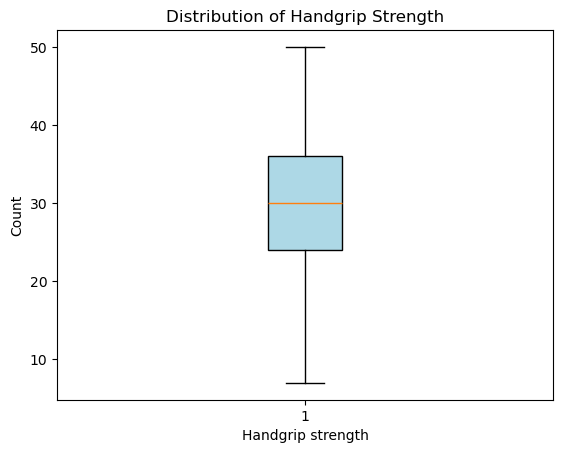

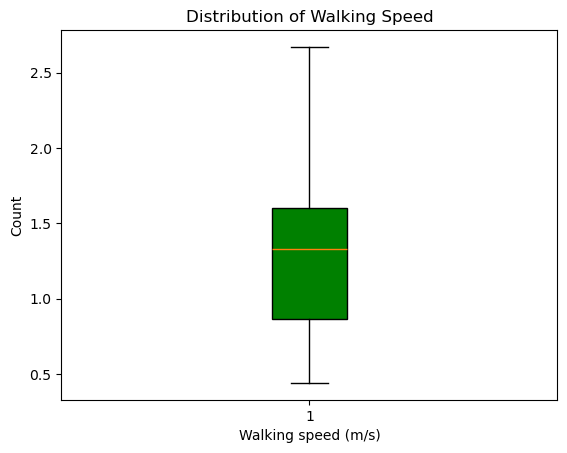

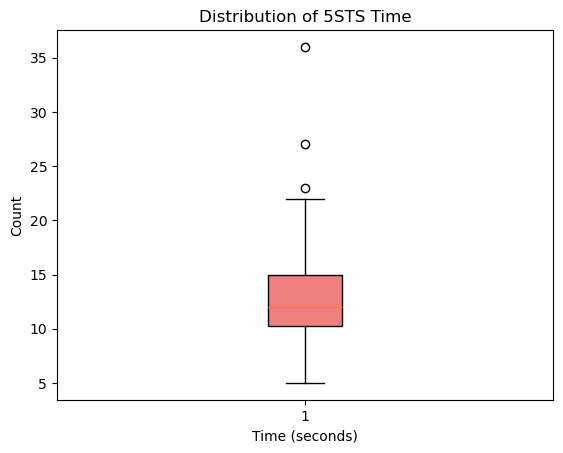

In [30]:
# Visualize the distribution of the main variables
plt.figure()
plt.boxplot(frapid_data_clean["handgrip_strength (kg)"], patch_artist=True, boxprops=dict(facecolor="lightblue", edgecolor="black", linewidth=1))
plt.title("Distribution of Handgrip Strength")
plt.xlabel("Handgrip strength")
plt.ylabel("Count")
plt.savefig("results/figures/handgrip_strength_distribution.png", dpi=300)
plt.show()

plt.figure()
plt.boxplot(frapid_data_clean["walking_speed_mps"], patch_artist=True, boxprops=dict(facecolor="green", edgecolor="black", linewidth=1))
plt.title("Distribution of Walking Speed")
plt.xlabel("Walking speed (m/s)")
plt.ylabel("Count")
plt.savefig("results/figures/walking_speed_distribution.png", dpi=300)
plt.show()

plt.figure()
plt.boxplot(frapid_data_clean["time_5_raise_chair (s)"], patch_artist=True, boxprops=dict(facecolor="lightcoral", edgecolor="black", linewidth=1))
plt.title("Distribution of 5STS Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.savefig("results/figures/5sts_time_distribution.png", dpi=300)
plt.show()

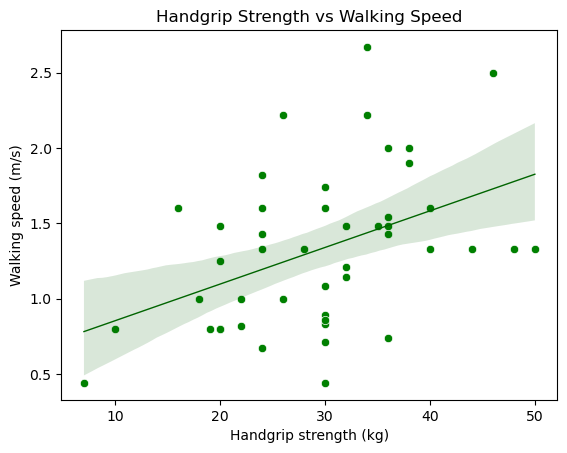

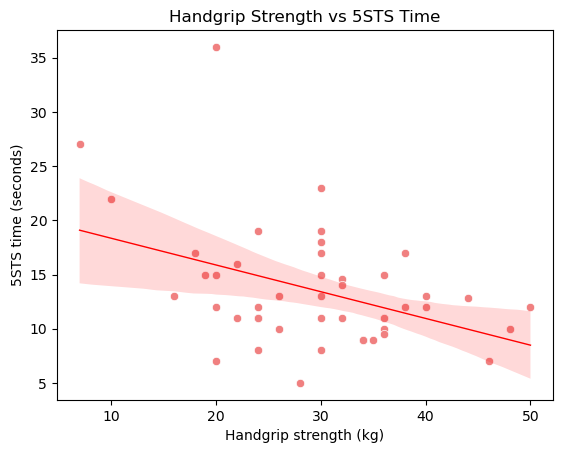

In [31]:
# Visualize the relationship between handgrip strength and walking speed, and handgrip strength and 5STS time

# Primary analysis: handgrip vs walking speed
plt.figure()
sns.scatterplot(data=frapid_data_clean, x="handgrip_strength (kg)", y="walking_speed_mps", color="green")
sns.regplot(data=frapid_data_clean, x="handgrip_strength (kg)", y="walking_speed_mps", scatter=False, color="darkgreen", line_kws={"linewidth": 1})
plt.title("Handgrip Strength vs Walking Speed")
plt.xlabel("Handgrip strength (kg)")
plt.ylabel("Walking speed (m/s)")
plt.savefig("results/figures/handgrip_vs_walking_speed_scatterplot.png", dpi=300)
plt.show()


# Secondary analysis: handgrip vs 5STS
import seaborn as sns
plt.figure()
sns.scatterplot(data=frapid_data_clean, x="handgrip_strength (kg)", y="time_5_raise_chair (s)", color="lightcoral")
sns.regplot(data=frapid_data_clean, x="handgrip_strength (kg)", y="time_5_raise_chair (s)", scatter=False, color="red", line_kws={"linewidth": 1})
plt.title("Handgrip Strength vs 5STS Time")
plt.xlabel("Handgrip strength (kg)")
plt.ylabel("5STS time (seconds)")
plt.savefig("results/figures/handgrip_vs_5sts_scatterplot.png", dpi=300)
plt.show()

Scatter plots were used to visually explore the relationship between handgrip strength and functional performance measures (walking speed and 5STS time). 

The scatter plots suggest a weak positive relationship between handgrip strength and walking speed, and a weak negative relationship between handgrip strength and 5STS time.